# SBERT Sentence Analysis

## 1. Preparations

### 1.1 Read Data
The sentence data were preprocessed (see preprocessing.ipynb)
In the dataframe:  
- "sentence" = preprocessed sentences with placeholders of anonymized information, **used for the analysis**
- "clean_sentence" = proprocessed sentences with placeholders removed,  
- "translated_sentence" = translated from "sentence" column to English with translate.ipynb

In [1]:
# first install numpy=1.26.4 before installing pandas and other packages
%pip install numpy==1.26.4
%pip install pandas openpyxl

import pandas as pd
# read the sentence data 
df = pd.read_excel("/workspace/persistent/mijnidbcoachnlp/data/analysis_data/sentence_data_for_analysis.xlsx", index_col=0)
sentences = df["sentence"].to_list()

# check the df head
df.head()

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


,message_id,sentence,clean_sentence,sentence_id,translated_sentence
0,1,"Geachte ibd groep, Is mijn uitslag al binnen ...","ibd groep, Is mijn uitslag al binnen van de b...",1,"Dear Ibd group, has my results come back from ..."
1,3,Vorige week is door [ZIEKENHUIS] [LOCATIE] mij...,Vorige week is door mijn ontlasting onderzoc...,2,Last week my stool was examined by [SIGHSHOUSE...
2,3,Graag zou ik de uitkomst hiervan vernemen.,Graag zou ik de uitkomst hiervan vernemen.,3,I would like to hear the outcome of this.
3,4,bloed in de ontlasting wordt steeds meer en st...,bloed in de ontlasting wordt steeds meer en st...,4,blood in the stool is becoming more and more f...
4,4,Ligt dit aan de medicatie?,Ligt dit aan de medicatie?,5,Is this because of the medication?


In [2]:
# check input size
len_data = len(sentences)
print(f"data size: {len_data}")

data size: 41119


In [3]:
### Importing the list of Dutch stopwords (note that there are customized dutch words in there)

with open('/workspace/persistent/mijnidbcoachnlp/data/analysis_data/stopwords_extended.txt', 'r') as file:
    lines = [line.strip() for line in file.readlines()]

dutch_stopwords = lines

In [4]:
%pip install gensim

import pickle
from gensim.corpora import Dictionary

# Load the tokenized texts
with open("/workspace/persistent/mijnidbcoachnlp/data/tokens/tokenized_sentences.pkl", "rb") as f:
    tokenized_texts = pickle.load(f)

dictionary = Dictionary(tokenized_texts)

Note: you may need to restart the kernel to use updated packages.


### 1.2 Embed the lists of sentences (Commented Out)
In this section, we embed the sentence data with five differen sentence transformer models available on Hugging Face. Only run once.

In [5]:
%pip install sentence_transformers

from sentence_transformers import SentenceTransformer
from tqdm.autonotebook import tqdm  
import numpy as np
import sentence_transformers.util
import os 
import numpy as np

def embed_and_save(docs, embedding_model, save_path):
    """Generate embeddings for documents and save them with model name in the filename."""
    embeddings = embedding_model.encode(docs, show_progress_bar=True)
    
    # Use model class name as identifier
    model_name = embedding_model.__class__.__name__
    
    # Create the full file path
    file_name = f'embeddings_{model_name}.npy'
    file_path = os.path.join(save_path, file_name)
    
    # Save the embeddings
    np.save(file_path, embeddings)

    # print saved embeddings
    print(f"Embedding saved successfully to {file_path}")

Note: you may need to restart the kernel to use updated packages.


/root/anaconda3/envs/env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# list of all embedding models to try out
#from sentence_transformers import SentenceTransformer

#embedding_models = [
    #("stv1", SentenceTransformer("distiluse-base-multilingual-cased-v1")),
    #("stv2", SentenceTransformer("distiluse-base-multilingual-cased-v2")),
    #("mini", SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")),
    #("mpnet", SentenceTransformer("paraphrase-multilingual-mpnet-base-v2")),
    #("robbert", SentenceTransformer("NetherlandsForensicInstitute/robbert-2022-dutch-sentence-transformers")),
    #("e5", SentenceTransformer("intfloat/multilingual-e5-large-instruct", trust_remote_code=True))
#]

In [7]:
# embed the documents with all embedding models

#for (name, embedding_model) in embedding_models:
    #save_path = "/workspace/persistent/mijnidbcoachnlp/data/embeddings_full_docs"
    # embed all the sentences
    #embed_and_save(docs=sentences, embedding_model=embedding_model, save_path=save_path)
    #print("All embeddings saved successfully.")

### 1.3 Load embeddings

In [8]:
import numpy as np
from sentence_transformers import SentenceTransformer

# Define model names and embeddings
models_and_embeddings = [
    ("stv1", SentenceTransformer("distiluse-base-multilingual-cased-v1"), np.load("/workspace/persistent/mijnidbcoachnlp/data/embeddings_full_docs/embeddings_st_v1_sentence_placeholder.npy")),
    ("stv2", SentenceTransformer("distiluse-base-multilingual-cased-v2"), np.load("/workspace/persistent/mijnidbcoachnlp/data/embeddings_full_docs/embeddings_st_v2_sentence_placeholder.npy")),
    ("mini", SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2"), np.load("/workspace/persistent/mijnidbcoachnlp/data/embeddings_full_docs/embeddings_st_miniL12v2_sentence_placeholder.npy")),
    ("mpnet", SentenceTransformer("paraphrase-multilingual-mpnet-base-v2"), np.load("/workspace/persistent/mijnidbcoachnlp/data/embeddings_full_docs/embeddings_st_mpnet_v2_sentence_placeholder.npy")),
    ("robbert", SentenceTransformer("NetherlandsForensicInstitute/robbert-2022-dutch-sentence-transformers"), np.load("/workspace/persistent/mijnidbcoachnlp/data/embeddings_full_docs/embeddings_st_robbert2022_sentence_placeholder.npy")),
    ("e5", SentenceTransformer("intfloat/multilingual-e5-large-instruct", trust_remote_code=True), np.load("/workspace/persistent/mijnidbcoachnlp/data/embeddings_full_docs/embeddings_e5.npy"))
]

In [9]:
models_and_embeddings_dict = {
    name: (model, embedding)
    for name, model, embedding in models_and_embeddings
}

In [10]:
# disable parallelism to avoid some warnings
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

#### 1.4. Initializa BERTopic settings

In [11]:
%pip install umap-learn hdbscan 

from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

# Shared settings with multiple representation models
bertopic_settings = {
    "vectorizer_model": CountVectorizer(stop_words=dutch_stopwords, min_df=2, ngram_range=(1, 1), token_pattern=r'\b[a-zA-Z]{3,}\b'),
    "calculate_probabilities": False,
    "verbose": False
    #"representation_model": {
        #"Default": "default",  # This uses the default c-TF-IDF representation
        #"KeyBERTInspired": KeyBERTInspired()
    #}
}

Note: you may need to restart the kernel to use updated packages.


## 3. Coarse Grid Search

### 3.1 Preparations for grid search

In [12]:
# sample the sentences and their embeddings for tuning on a smaller sample 

import random

# Set seed for reproducibility
random.seed(1234)

# Sample indices instead of sentences
sample_size = int(0.2 * len(sentences))
sample_indices = random.sample(range(len(sentences)), sample_size)

# Get the sampled sentences and their embeddings
sampled_sentences = [sentences[i] for i in sample_indices]

# create tokens and dictionary for the sample
sampled_tokens = [tokenized_texts[i] for i in sample_indices]
sample_dictionary = Dictionary(sampled_tokens)

sampled_models_and_embeddings = []

for name, embedding_model, embeddings in models_and_embeddings:
    sampled_embeddings = embeddings[sample_indices]
    sampled_models_and_embeddings.append((name, embedding_model, sampled_embeddings))



In [13]:
sampled_models_and_embeddings_dict = {
    name: (model, embedding)
    for name, model, embedding in sampled_models_and_embeddings
}

In [14]:
# function to return top n words 
# function to get top words
from typing import List

def get_top_words(topic_model, top_n: int) -> List[List[str]]:
    """Extract top words for each topic from BERTopic (excluding outliers and empty words)."""
    topics = topic_model.get_topics()  # topics is a dict: {topic_num: [(word, score), ...]}
    top_words = []
    for topic_num, word_score_list in topics.items():
        if topic_num == -1:
            continue  # Skip outlier topic (-1)
        words = [word for word, _ in word_score_list[:top_n] if word.strip()]  # Skip empty words
        if words:  # Only append if the words list is not empty
            top_words.append(words)
    return top_words


In [15]:
%pip install octis

# functions for diversity, number of topics and coherence
from octis.evaluation_metrics.diversity_metrics import TopicDiversity
from collections import defaultdict
from typing import List

# function to evaluate topic diversity
def get_topic_diversity(top_words, topk=10):
    metric = TopicDiversity(topk=topk)
    diversity_score = metric.score({"topics": top_words}) 
    return diversity_score

# function to calculate coverage
def get_coverage(topic_model):
    """Calculate the proportion of documents assigned to valid topics (topic != -1)."""
    topics = topic_model.topics_
    valid_topic_count = sum(1 for topic in topics if topic != -1)
    return valid_topic_count / len(topics)

def get_nr_topics(topic_model):
    topic_info = topic_model.get_topic_info()
    # Exclude the outlier class (-1) if you want only real topics
    nr_topics = topic_info[topic_info.Topic != -1].shape[0]
    return nr_topics

from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

def get_c_v(topic_model, tokenized_texts, dictionary, top_words):
    
    # Prepare CoherenceModel
    coherence_model = CoherenceModel(
        topics=top_words,
        texts=tokenized_texts,
        dictionary=dictionary,
        coherence='c_v'
    )
    
    # Compute coherence
    coherence_score = coherence_model.get_coherence()
    
    return coherence_score


  Using cached scikit_learn-1.1.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (10 kB)
Using cached scikit_learn-1.1.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (30.7 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.7.0
    Uninstalling scikit-learn-1.7.0:
      Successfully uninstalled scikit-learn-1.7.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.8 requires scikit-learn>=1.6, but you have scikit-learn 1.1.0 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [16]:
# functions to calculate embedding coherence
from typing import List, Tuple, Dict
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

def cluster_coherence(embeddings: np.ndarray) -> float:
    """
    Compute the average pairwise cosine similarity among embeddings.
    If only one item in cluster, returns NaN.
    """
    n = embeddings.shape[0]
    if n < 2:
        return np.nan
    sim_mat = cosine_similarity(embeddings)
    iu = np.triu_indices(n, k=1)
    return sim_mat[iu].mean()

def get_intra_topic_similarity(
    topic_model, 
    sentences: List[str], 
    embeddings: np.ndarray
) -> Tuple[float, float, Dict[int, float]]:
    document_info = topic_model.get_document_info(sentences)
    clusters = document_info['Topic'].to_list()

    df = pd.DataFrame({
        'sentence': sentences,
        'embedding': list(embeddings),
        'cluster': clusters
    })

    total_weighted_sim = 0.0
    total_docs = 0
    similarities = []

    for cluster_label, group in df.groupby('cluster'):
        if cluster_label == -1:
            continue  # Skip outlier topic

        embs = np.vstack(group['embedding'].values)
        mean_sim = cluster_coherence(embs)
        cluster_size = len(group)

        if not np.isnan(mean_sim):
            similarities.append(mean_sim)

            total_weighted_sim += mean_sim * cluster_size
            total_docs += cluster_size

    # Compute weighted and unweighted averages
    weighted_mean_sim = total_weighted_sim / total_docs if total_docs > 0 else np.nan
    unweighted_mean_sim = np.mean(similarities) if similarities else np.nan

    return weighted_mean_sim, unweighted_mean_sim


In [17]:
# initialize the range of parameters for coarse grid search

min_cluster_sizes = [10, 20, 30, 40]
range_n_components = [5, 10, 15]
range_n_neighbors = [10, 20, 30, 40]

from itertools import product

# Generate all combinations
coarse_param_combinations = list(product(
    min_cluster_sizes, 
    range_n_components,
    range_n_neighbors, 
))

print(f"Total combinations of coarse grid search for each model: {len(coarse_param_combinations)}")

Total combinations of coarse grid search for each model: 48


### 3.1 Coarse search with param combinations and 20% sample docs

In [18]:
# scikit-learn must be upgraded here to avoid dependency conflic
%pip install -upgrade scikit-learn
%pip install bertopic

from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic

# function for grid search
def coarse_grid_search(docs, models_and_embeddings, param_combinations, tokenized_texts, dictionary):
    metrics_vs_combination = defaultdict(dict)

    # use sampled docs instead of full docs
    for name, embedding_model, embeddings in models_and_embeddings:
        metrics_results_model = defaultdict(dict)
        # search over min_cluster_size
        for combination in param_combinations:

            # access the three params
            min_cluster_size, n_components, n_neighbors = combination
            
            # initialize a topic model with the basic setting
            topic_model = BERTopic(**bertopic_settings)
            
            # update the hdbscan model and umap model with the three parameters
            topic_model.hdbscan_model = HDBSCAN(min_cluster_size=min_cluster_size, metric='euclidean', cluster_selection_method='eom', prediction_data=False)
            topic_model.umap_model = UMAP(n_neighbors=n_neighbors, n_components=n_components, min_dist=0.0, metric='cosine', random_state=42)
            print(f"Tuning model: {name} at param combination: min_cluster_size = {min_cluster_size}, n_components = {n_components}, n_neighbors = {n_neighbors}")

            topics, probs = topic_model.fit_transform(docs, embeddings)


            coverage = get_coverage(topic_model)
            nr_topics = get_nr_topics(topic_model)
            
            print(f"Document: {coverage}")
            print(f"Number of topics: {nr_topics}")


            #min_topic_threshold = len(docs) // 200 # min number of topics is set at 200 docs per topic
            
            top_words = get_top_words(topic_model, top_n=10)
            try:
                diversity_score = get_topic_diversity(top_words)
                print(f"Diversity score: {diversity_score}")
            
                c_v_score = get_c_v(topic_model, tokenized_texts, dictionary, top_words)
                print(f"C_V coherence: {c_v_score}")
            except Exception:
                c_v_score = None
                diversity_score = None
                print("Exception Error")

            weighted_sim, unweighted_sim = get_intra_topic_similarity(
                topic_model, docs, embeddings
            )
            print(f"Average embedding cosine similarity weighted: {weighted_sim}, unweighted: {unweighted_sim}")
            print(" ")

            metrics_vs_combination[(name, combination)]["min_cluster_size"] = min_cluster_size
            metrics_vs_combination[(name, combination)]["n_components"] = n_components
            metrics_vs_combination[(name, combination)]["n_neighbors"] = n_neighbors
            metrics_vs_combination[(name, combination)]["diversity_score"] = diversity_score
            metrics_vs_combination[(name, combination)]["c_v_score"] = c_v_score

            metrics_vs_combination[(name, combination)]["weighted_avg_sim"] = weighted_sim
            metrics_vs_combination[(name, combination)]["unweighted_avg_sim"] = unweighted_sim
            metrics_vs_combination[(name, combination)]["document_coverage"] = coverage
            metrics_vs_combination[(name, combination)]["number_of_topics"] = nr_topics
        
            metrics_results_model = metrics_vs_combination
                # Save results to a file
            with open(f'/workspace/persistent/mijnidbcoachnlp/new_analysis/results/results_per_model/coarse_results_{name}.pkl', 'wb') as f:
                pickle.dump(metrics_results_model, f)
            

    return metrics_vs_combination


Usage:   
  /root/anaconda3/envs/env/bin/python -m pip install [options] <requirement specifier> [package-index-options] ...
  /root/anaconda3/envs/env/bin/python -m pip install [options] -r <requirements file> [package-index-options] ...
  /root/anaconda3/envs/env/bin/python -m pip install [options] [-e] <vcs project url> ...
  /root/anaconda3/envs/env/bin/python -m pip install [options] [-e] <local project path> ...
  /root/anaconda3/envs/env/bin/python -m pip install [options] <archive url/path> ...

no such option: -u
Note: you may need to restart the kernel to use updated packages.
  Using cached scikit_learn-1.7.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (17 kB)
Using cached scikit_learn-1.7.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.9 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.1.0
    Uninstalling scikit-learn-1.1.0:
      Successfully uninstalled scikit-learn-1.1.0
ERROR: pip's depen

In [20]:
# coarse grid search with sampled sentences
# coarse_metrics_results, coarse_similarities_results = coarse_grid_search(docs=sampled_sentences, models_and_embeddings=sampled_models_and_embeddings, param_combinations=coarse_param_combinations, tokenized_texts=sampled_tokens, dictionary=sample_dictionary)

# save the results
# load the coarse metrics results
#with open('/workspace/persistent/mijnidbcoachnlp/new_analysis/results/coarse_sample_results.pkl', 'wb') as f:
    #pickle.dump(coarse_metrics_results, f)

# load the coarse metrics results
#with open('/workspace/persistent/mijnidbcoachnlp/new_analysis/results/coarse_sample_results_similarities.pkl', 'wb') as f:
    #pickle.dump(coarse_similarities_results, f)

In [21]:
# coarse grid search with entire data
#coarse_metrics_results = coarse_grid_search(
    #docs=sentences,
    #models_and_embeddings=models_and_embeddings[3:],
    #param_combinations=coarse_param_combinations,
    #tokenized_texts=tokenized_texts,
    #dictionary=dictionary
#)

Tuning model: mpnet at param combination: min_cluster_size = 10, n_components = 5, n_neighbors = 10
Document: 0.6222913981371142
Number of topics: 593
Diversity score: 0.5443507588532883
C_V coherence: 0.3540491919303406
Average embedding cosine similarity weighted: 0.6798450057257223, unweighted: 0.7253327369689941
 
Tuning model: mpnet at param combination: min_cluster_size = 10, n_components = 5, n_neighbors = 20
Document: 0.6095722172231814
Number of topics: 473
Diversity score: 0.5714587737843552
C_V coherence: 0.3536111619364211
Average embedding cosine similarity weighted: 0.6716500048280214, unweighted: 0.7305719256401062
 
Tuning model: mpnet at param combination: min_cluster_size = 10, n_components = 5, n_neighbors = 30
Document: 0.5997957148763345
Number of topics: 426
Diversity score: 0.573943661971831
C_V coherence: 0.35666222221299293
Average embedding cosine similarity weighted: 0.6693038262612038, unweighted: 0.7329732775688171
 
Tuning model: mpnet at param combination

In [ ]:
#import pickle

# Save results to a file
#with open('/workspace/persistent/mijnidbcoachnlp/new_analysis/results/coarse_sample_results.pkl', 'wb') as f:
    #pickle.dump(coarse_metrics_results, f)

## 4. Observe metric trends over different parameters

In [37]:
# load the results data
with open(f'/workspace/persistent/mijnidbcoachnlp/new_analysis/results/results_per_model/coarse_results_mini.pkl', 'rb') as f:
    model_results = pickle.load(f)

In [45]:
import os
import pickle
import pandas as pd

# Directory containing your pickle files
results_dir = '/workspace/persistent/mijnidbcoachnlp/new_analysis/results/results_per_model'

# List to collect all rows from all pickle files
all_rows = []

# Iterate through all .pkl files in the directory
for filename in os.listdir(results_dir):
    if filename.endswith('.pkl'):
        filepath = os.path.join(results_dir, filename)
        with open(filepath, 'rb') as f:
            model_results = pickle.load(f)

        # Flatten the dictionary into a list of records
        for (name, combination), metrics in model_results.items():
            row = {
                "model_name": name,
                "combination": combination,
                **metrics
            }
            all_rows.append(row)

# Create a DataFrame
df = pd.DataFrame(all_rows)

# Drop duplicate rows
df = df.drop_duplicates()

# Optionally, reset index
df.reset_index(drop=True, inplace=True)

# Show the result
df.head()


,model_name,combination,min_cluster_size,n_components,n_neighbors,diversity_score,c_v_score,weighted_avg_sim,unweighted_avg_sim,document_coverage,number_of_topics
0,mpnet,"(10, 5, 10)",10,5,10,0.544351,0.354049,0.679845,0.725333,0.622291,593
1,mpnet,"(10, 5, 20)",10,5,20,0.571459,0.353611,0.671650,0.730572,0.609572,473
2,mpnet,"(10, 5, 30)",10,5,30,0.573944,0.356662,0.669304,0.732973,0.599796,426
3,mpnet,"(10, 5, 40)",10,5,40,0.570352,0.362682,0.673390,0.738545,0.577324,399
4,mpnet,"(10, 10, 10)",10,10,10,0.542784,0.355318,0.672597,0.729800,0.651791,582


In [93]:
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import pandas as pd


def visualize_trends_permodel(model_name, parameter_to_plot, main_color):

    df_model = df[df["model_name"] == model_name]



    parameters = ["min_cluster_size", "n_components", "n_neighbors"]

    # Metrics to plot
    metrics = [
        "c_v_score",
        "unweighted_avg_sim",
        "document_coverage",
        "diversity_score"
    ]

    # Acceptable number of topics range
    min_topics, max_topics = 50, 350

    # Parameters to group by (besides min_cluster_size)
    group_params = [x for x in parameters if x != parameter_to_plot]

    # create sub-plots
    fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(20, 5), sharex=True)

    # Normalize each metric column for this model
    scaler = MinMaxScaler()
    df_model[metrics] = scaler.fit_transform(df_model[metrics])



    for ax, metric in zip(axes, metrics):

        # Custom x-ticks for discrete param
        if parameter_to_plot == "n_components":
            unique_vals = sorted(df_model["n_components"].unique())
            ax.set_xticks(unique_vals)

        in_range = (df_model["number_of_topics"] >= min_topics) & (df_model["number_of_topics"] <= max_topics)
        out_range = ~in_range

        # Scatter plots
        ax.scatter(df_model[parameter_to_plot][out_range], df_model[metric][out_range],
                color="lightgrey", alpha=0.3, label="Out of range")

        ax.scatter(df_model[parameter_to_plot][in_range], df_model[metric][in_range],
                color=main_color, alpha=0.5, label="In range")

        # ✅ Overall mean trend (all points)
        mean_all = df_model.groupby(parameter_to_plot)[metric].mean()
        ax.plot(mean_all.index, mean_all.values, color="black", linestyle="--", marker="o", label="Mean (All)")

        # Mean trend
        mean_in = df_model[in_range].groupby(parameter_to_plot)[metric].mean()
        ax.plot(mean_in.index, mean_in.values, color=main_color, marker="o", label="Mean (In range)")


        # Connect points for same (number_of_topics, cluster_selection_epsilon)
        grouped = df_model.groupby(group_params)

        for (topics, epsilon), group in grouped:
            group_sorted = group.sort_values(parameter_to_plot)
            ax.plot(
                group_sorted[parameter_to_plot],
                group_sorted[metric],
                color="blue" if (min_topics <= topics <= max_topics) else "grey",
                alpha=0.3,
                linewidth=1
            )

        # Formatting
        ax.set_title(metric.replace("_", " ").title())
        ax.set_ylabel(metric.replace("_", " ").title())
        ax.set_xlabel(parameter_to_plot)
        ax.grid(True)

    # Shared legend (only once)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")

    # Overall title
    fig.suptitle(f"Metric Trends vs {parameter_to_plot} with In/Out Topic Ranges — Model {model_name}", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

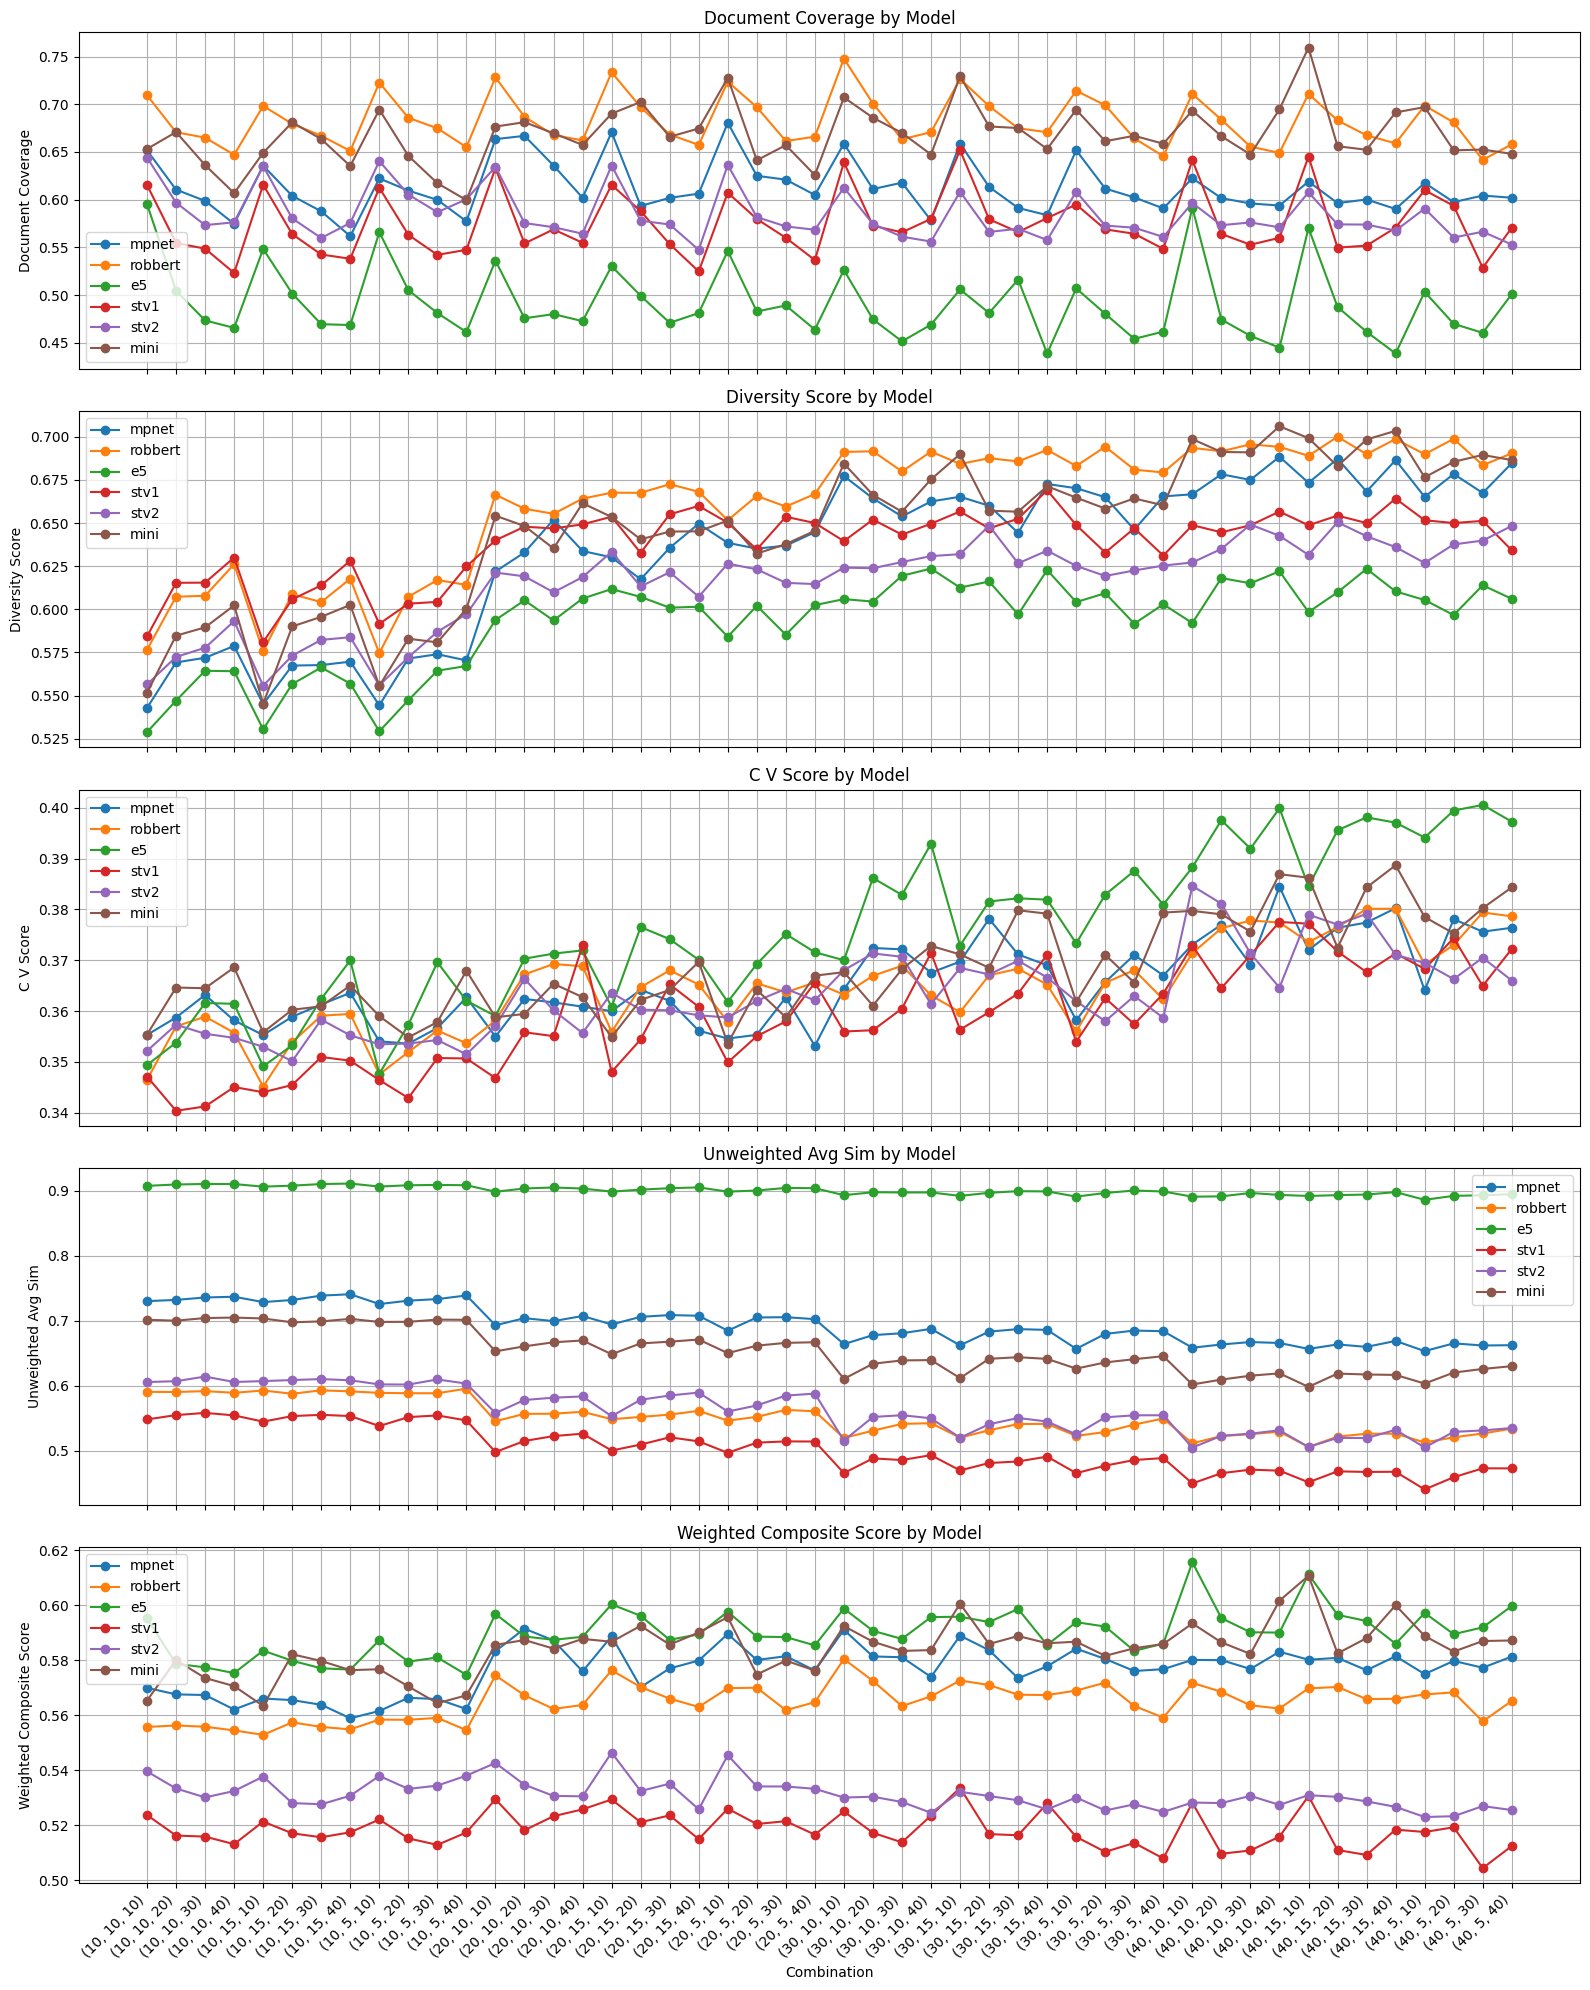

In [54]:
import matplotlib.pyplot as plt
import pandas as pd

# Define weights for composite score
weights = {
    'document_coverage': 0.25,
    'diversity_score': 0.25,
    'c_v_score': 0.25,
    'unweighted_avg_sim': 0.25
}

# Ensure 'combination' is string-type
df['combination'] = df['combination'].astype(str)

# Compute weighted composite score
df['weighted_composite_score'] = sum(
    df[metric] * weight for metric, weight in weights.items()
)

# All metrics to plot
metrics_to_plot = list(weights.keys()) + ['weighted_composite_score']

# Get all unique combinations in order
all_combinations = sorted(df['combination'].unique())

# Create subplots (5 rows, 1 column)
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(16, 20), sharex=True)

# Loop over each metric
for ax, metric in zip(axes, metrics_to_plot):
    for model in df['model_name'].unique():
        df_model = df[df['model_name'] == model][['combination', metric]]
        df_model = df_model.set_index('combination').reindex(all_combinations)
        
        ax.plot(
            all_combinations,
            df_model[metric],
            label=model,
            marker='o'
        )
    
    ax.set_ylabel(metric.replace('_', ' ').title())
    ax.grid(True)
    ax.legend()
    ax.set_title(f'{metric.replace("_", " ").title()} by Model')

# Format the bottom x-axis
axes[-1].set_xticks(range(len(all_combinations)))
axes[-1].set_xticklabels(all_combinations, rotation=45, ha='right')
axes[-1].set_xlabel('Combination')

plt.tight_layout()
plt.show()


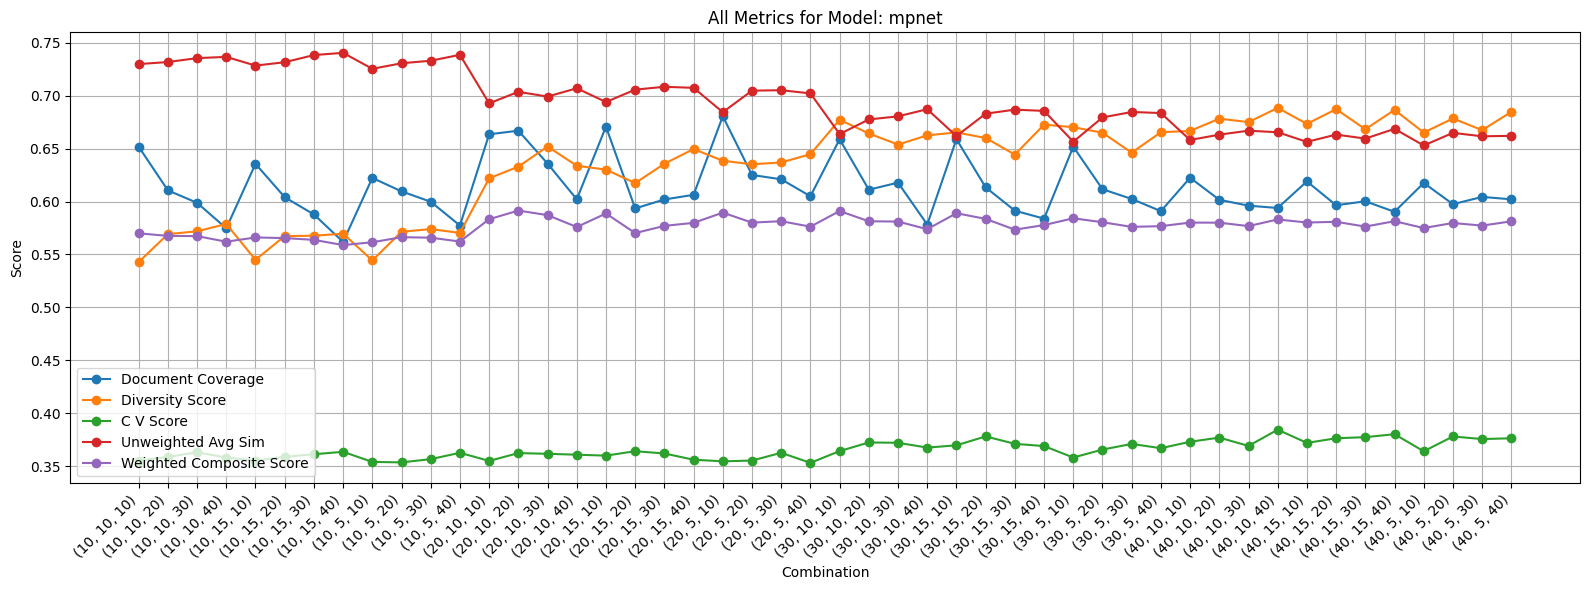

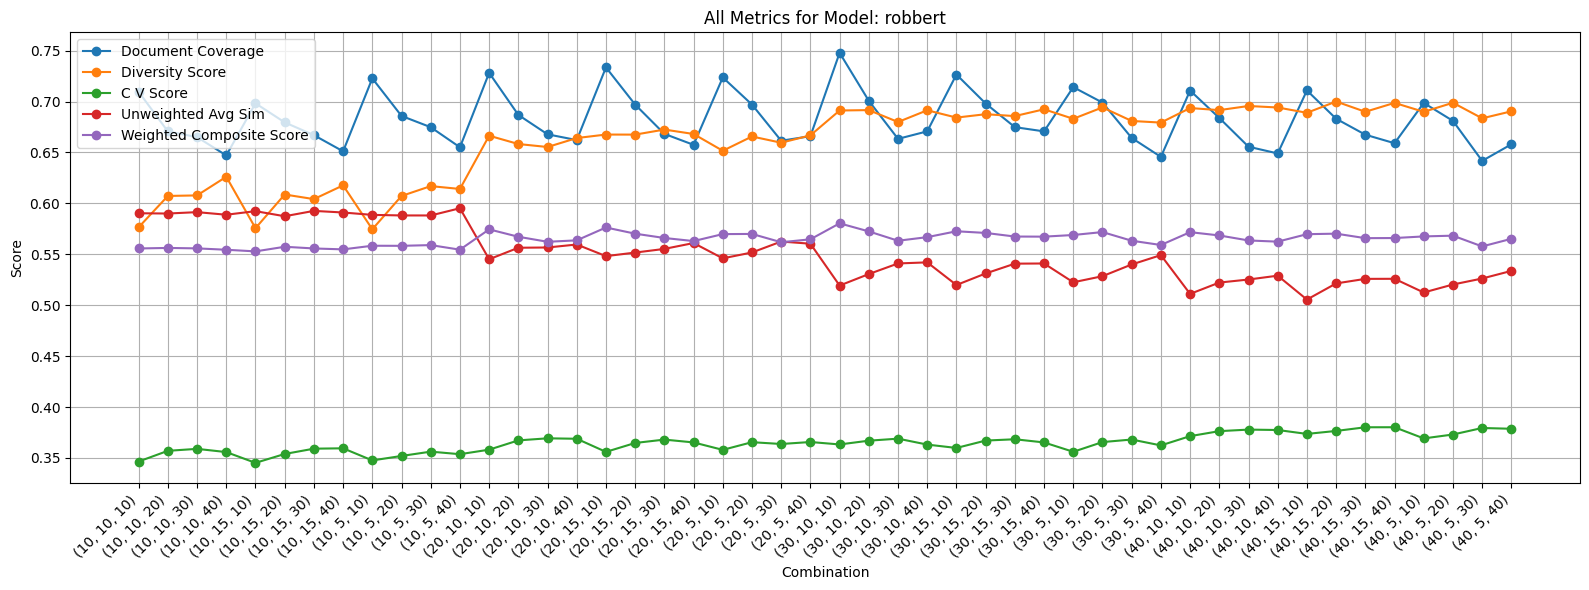

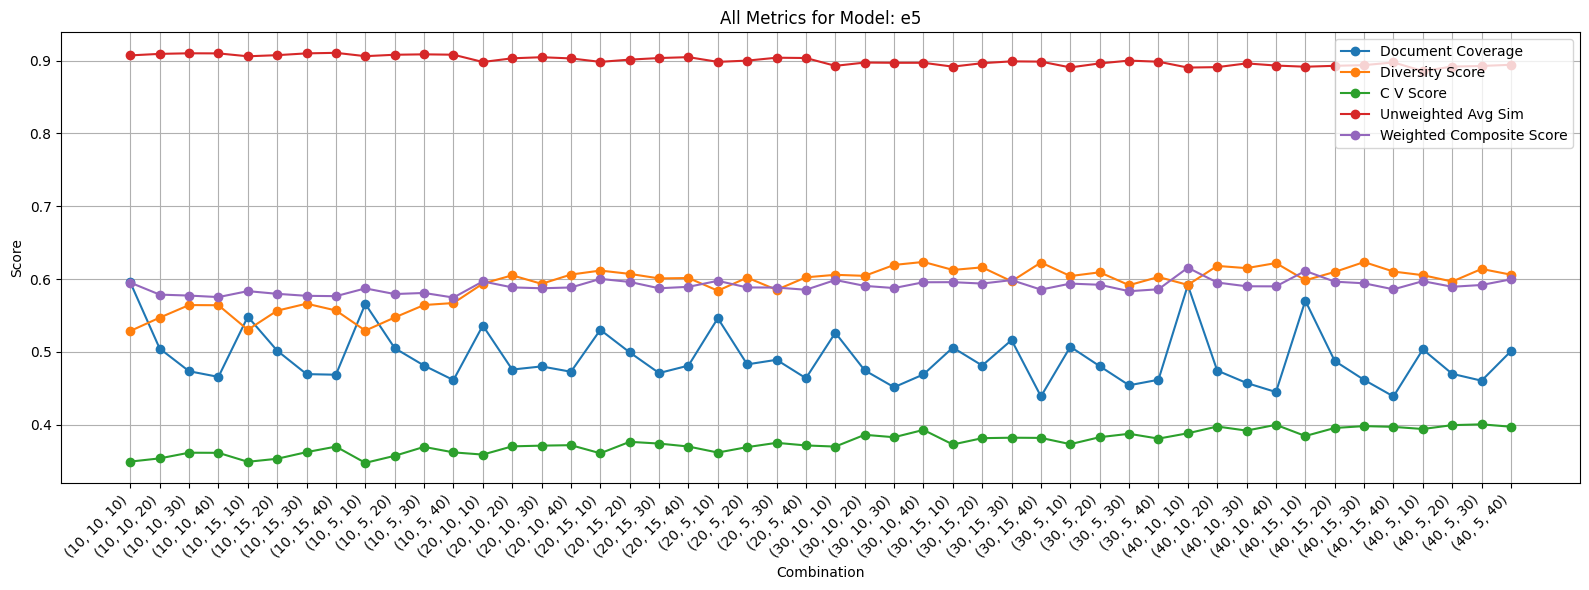

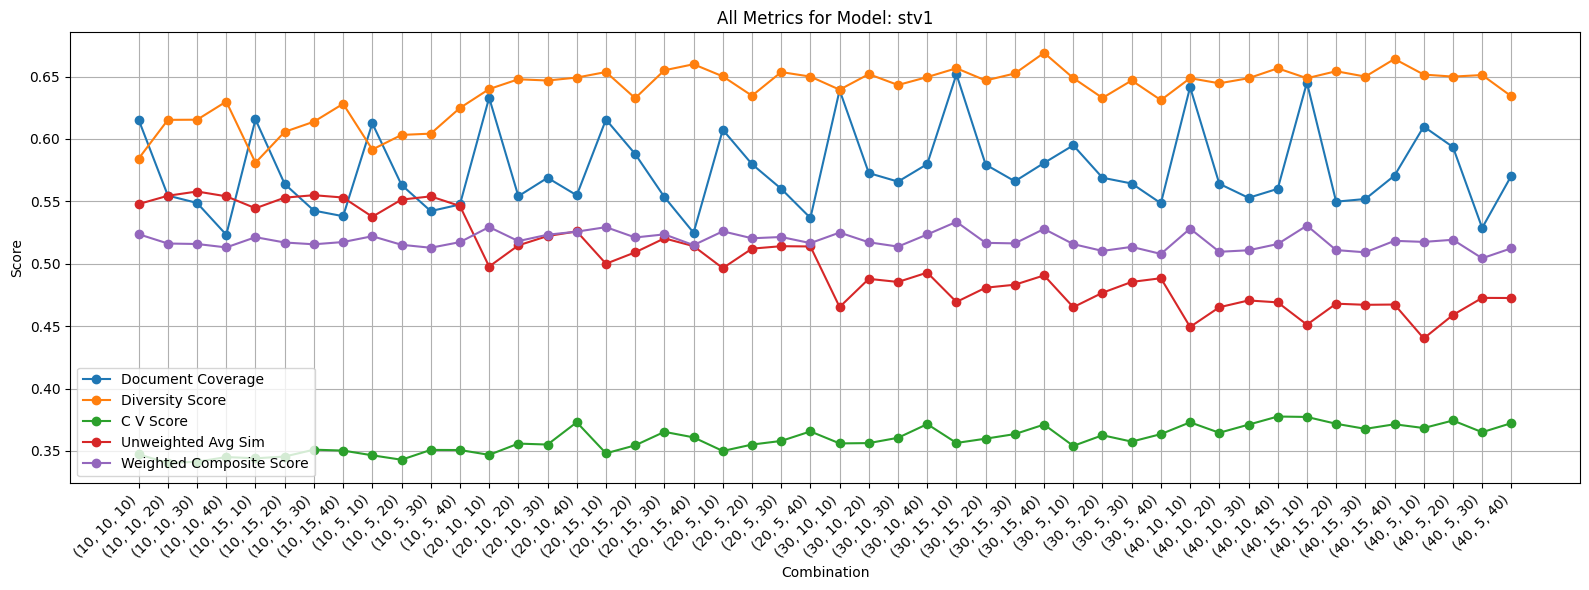

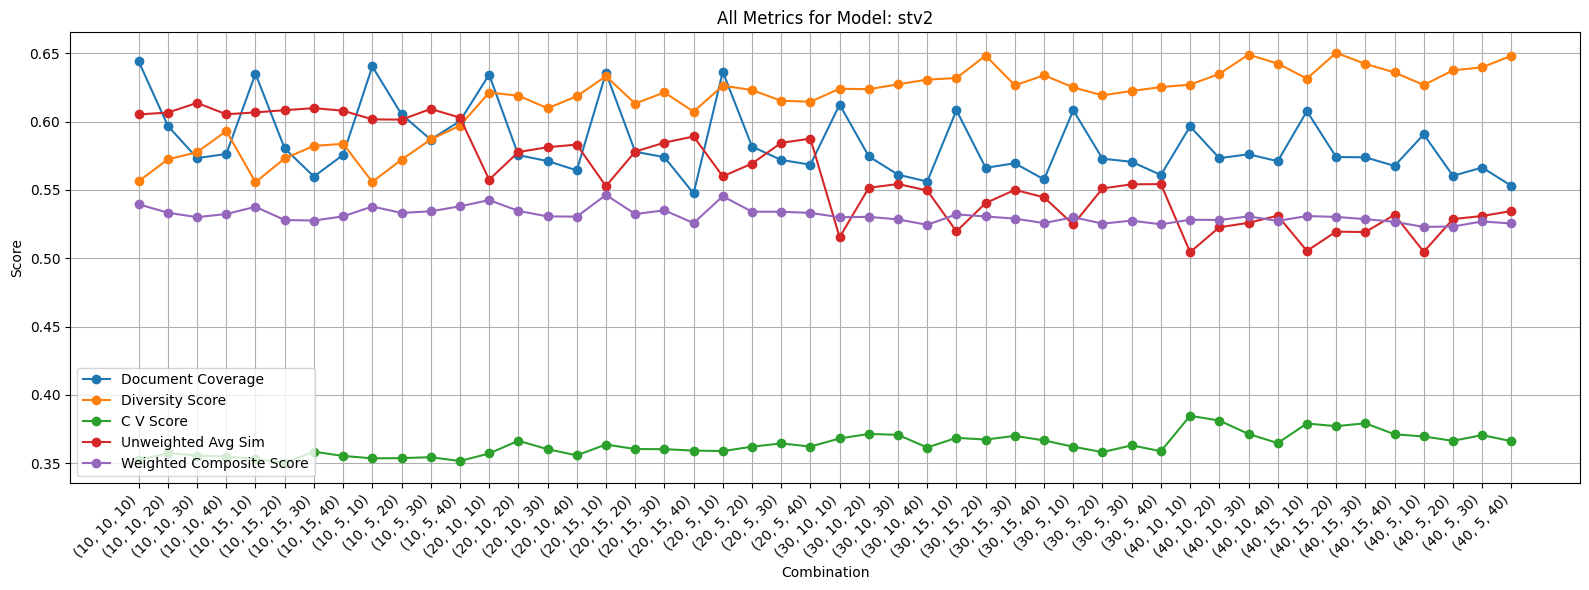

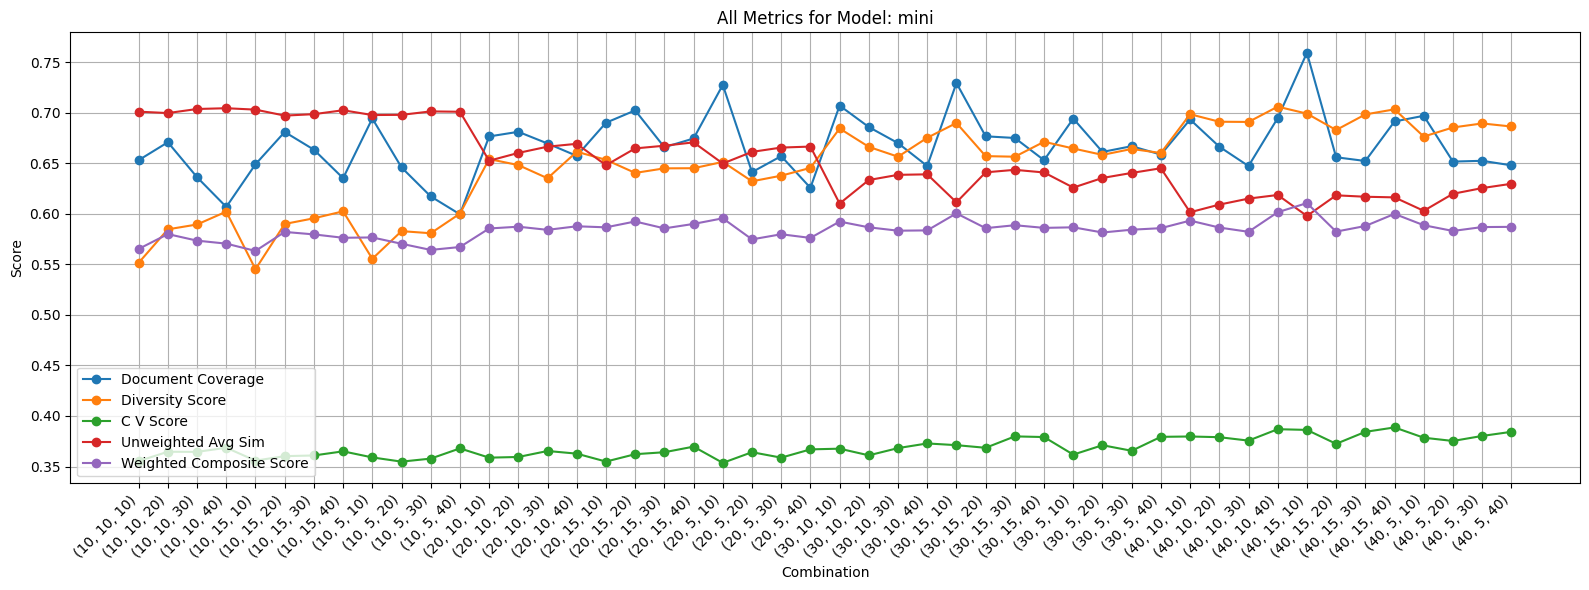

In [55]:
import matplotlib.pyplot as plt
import pandas as pd

# Define weights for composite score
weights = {
    'document_coverage': 0.25,
    'diversity_score': 0.25,
    'c_v_score': 0.25,
    'unweighted_avg_sim': 0.25
}

# Metrics to plot
metrics = [
    "c_v_score",
    "unweighted_avg_sim",
    "document_coverage",
    "diversity_score"
]

# Ensure 'combination' is string-type
df['combination'] = df['combination'].astype(str)

# Compute weighted composite score
df['weighted_composite_score'] = sum(
    df[metric] for metric in metrics.items()
)

# All metrics to plot
metrics_to_plot = list(weights.keys()) + ['weighted_composite_score']

# Get all unique combinations in order
all_combinations = sorted(df['combination'].unique())

# Plot one figure per model
for model in df['model_name'].unique():
    plt.figure(figsize=(16, 6))
    df_model = df[df['model_name'] == model].copy()
    df_model = df_model.set_index('combination').reindex(all_combinations)

    for metric in metrics_to_plot:
        plt.plot(
            all_combinations,
            df_model[metric],
            label=metric.replace('_', ' ').title(),
            marker='o'
        )

    plt.title(f'All Metrics for Model: {model}')
    plt.xlabel('Combination')
    plt.ylabel('Score')
    plt.xticks(rotation=45, ha='right')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


#### Results for GROW Science Day

In [24]:
'''
from bertopic import BERTopic

embedding_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
embeddings =  np.load("/workspace/persistent/mijnidbcoachnlp/data/embeddings/embeddings_st_miniL12v2_sentence_placeholder.npy")

topic_model = BERTopic(**bertopic_settings)
topic_model.hdbscan_model = HDBSCAN(min_cluster_size=25, metric='euclidean', cluster_selection_method='eom', prediction_data=False)
topic_model.umap_model = UMAP(n_neighbors=15, n_components=6, min_dist=0.0, metric='cosine', random_state=42)
topics, probs = topic_model.fit_transform(sentences, embeddings)

'''

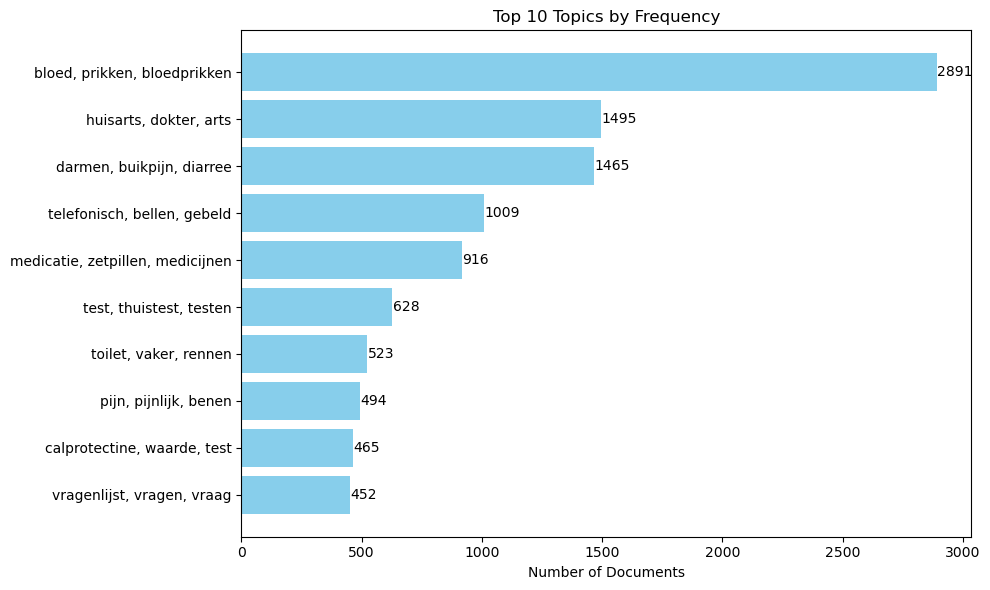

In [31]:
'''
import matplotlib.pyplot as plt

# Get topic info
topic_info = topic_model.get_topic_info()

# Exclude outlier topic -1 and get top 10 topics
top_10 = topic_info[topic_info.Topic != -1].head(10)

# Prepare labels: "Topic #ID: word1, word2, word3"
labels = [f"{', '.join(row['Representation'][:3])}" for _, row in top_10.iterrows()]
frequencies = top_10["Count"].values

# Plot
plt.figure(figsize=(10, 6))
bars = plt.barh(labels, frequencies, color="skyblue")
plt.xlabel("Number of Documents")
plt.title("Top 10 Topics by Frequency")
plt.gca().invert_yaxis()  # Highest at the top

# Optional: Add counts next to bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 2, bar.get_y() + bar.get_height()/2,
             f'{int(width)}', va='center')

plt.tight_layout()
plt.show()
'''

## 5. Testing out a combo

In [27]:
 # access the three params
test_combo = (30, 15, 10)
name = "stv1"
embeddings = models_and_embeddings_dict[name][1]
min_cluster_size, n_components, n_neighbors = test_combo

# initialize a topic model with the basic setting
topic_model = BERTopic(**bertopic_settings)

# update the hdbscan model and umap model with the three parameters
topic_model.hdbscan_model = HDBSCAN(min_cluster_size=min_cluster_size, metric='euclidean', cluster_selection_method='eom', prediction_data=False)
topic_model.umap_model = UMAP(n_neighbors=n_neighbors, n_components=n_components, min_dist=0.0, metric='cosine', random_state=42)
print(f"Tuning model: {name} at param combination: min_cluster_size = {min_cluster_size}, n_components = {n_components}, n_neighbors = {n_neighbors}")

topics, probs = topic_model.fit_transform(sentences, embeddings)

Tuning model: stv1 at param combination: min_cluster_size = 30, n_components = 15, n_neighbors = 10


In [29]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,14314,-1_afspraak_last_gaat_klachten,"[afspraak, last, gaat, klachten, contact, goed...",[Voor 12 okt staat er een afspraak gepland voo...
1,0,3604,0_apotheek_recept_medicatie_nieuw,"[apotheek, recept, medicatie, nieuw, medicijne...",[Zou u anders een nieuw recept kunnen sturen n...
2,1,3438,1_bloed_prikken_ontlasting_bloedprikken,"[bloed, prikken, ontlasting, bloedprikken, lat...","[Nog steeds veel bloed bij de ontlasting., Maa..."
3,2,1143,2_formulieren_mogelijk_sturen_opsturen,"[formulieren, mogelijk, sturen, opsturen, form...","[Kunt u de formulieren opsturen?, Ik heb hierv..."
4,3,769,3_test_testen_proberen_quanton,"[test, testen, proberen, quanton, cal, zelftes...","[Zal ik doen ,ik heb nog een test., Ik heb nog..."
...,...,...,...,...,...
153,152,32,152_bericht_hallo_dank_bedankt,"[bericht, hallo, dank, bedankt, dankjewel, ber...","[Hallo [PERSOON], Bedankt voor het bericht., ..."
154,153,32,153_samenwerkt_boumans_microlax_leverancier,"[samenwerkt, boumans, microlax, leverancier, s...","[wat moet ik nu doen weer microlax nemen?, Wat..."
155,154,32,154_reactie_gaarne_graag_uwerzijds,"[reactie, gaarne, graag, uwerzijds, befankt, r...","[Gaarne reactie op bovenstaand!, Gaarne jullie..."
156,155,32,155_fijne_groet_referentie_zonnige,"[fijne, groet, referentie, zonnige, paasdagen,...","[Groet en een fijne dag, [PERSOON], Groet en e..."


In [26]:
coverage = get_coverage(topic_model)
nr_topics = get_nr_topics(topic_model)

print(f"Document: {coverage}")
print(f"Number of topics: {nr_topics}")

Document: 0.5807777426493835
Number of topics: 126
